In [2]:
#зададим настройки темы

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import yticks

sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=0.8,
    rc={
        "axes.facecolor": "#FAF7F8",
        "figure.facecolor": "#FAF7F8",
        "grid.color": "#E5E0E2",
        "grid.linewidth": 0.8,
    }
)


sns.set_palette([
    "#E8A2B8",  # розовый
    "#9BC5A3",  # зелёный
    "#9B4F64",  # бордовый
    "#8FBBD9",  # голубой
    "#B39BC8",  # фиолетовый
])

In [3]:
import pandas as pd

x = pd.read_csv('../5. Обобщающая способность/Практика с кик старта/X.csv')
y = pd.read_csv('../5. Обобщающая способность/Практика с кик старта/Y.csv')

#оставим только небинарные колонки
cols_to_check = x[['Категория', 'Цель в долларах', 'Срок',
'Close_brent', 'Год публикации']]

#добавим в нашу матрицу таргет, чтобы смотреть на его связь с признаками
data = pd.concat((cols_to_check, y), axis=1)


_Посмотрим на корреляцию._

In [4]:
temp = data.corr()

_Изобразим, используя тепловую карту._

<Axes: >

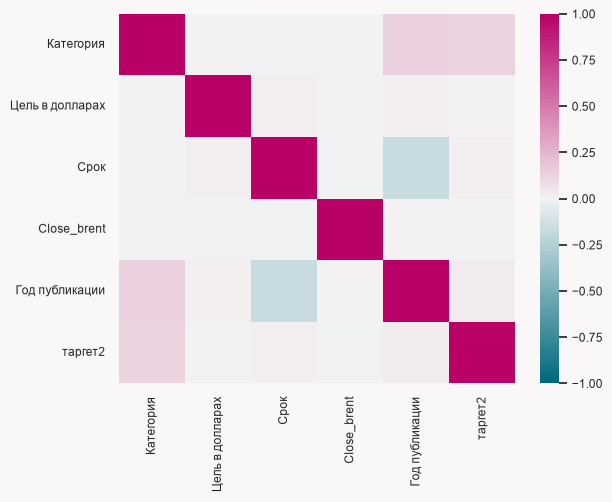

In [5]:
import seaborn as sns
sns.heatmap(temp,
            xticklabels=temp.columns,
            yticklabels=temp.columns,
            cmap=sns.diverging_palette(
        220, 350,
        s=100,
        l=40,
        as_cmap=True
    ),
    vmin=-1,
    vmax=1,
    center=0
)


_Видим, что есть небольшая корреляция между сроком и годом публикации. Также видим, что большая часть признаков не имеет линейной взаимосвязи с таргетом._

### **Подсчёт дисперсии.**

_Дисперсия — это мера того, насколько сильно значения разбросаны относительно их среднего._

_Если дисперсия маленькая, то признак почти не имеет смысла._

_Константная → вообще все значения одинаковые.
Квазиконстантная → почти все значения одинаковые._

In [7]:
from sklearn.feature_selection import VarianceThreshold

#установим значение дисперсии, ниже которого мы будем считать признак константным
variance = VarianceThreshold(threshold=1)

variance.fit(cols_to_check)

variance.get_feature_names_out()

array(['Категория', 'Цель в долларах', 'Срок', 'Год публикации'],
      dtype=object)